-------------**STRATEJİLER: MACD**----------


İşte teknik analiz temelli bir yatırım stratejisi örneği: MACD (Moving Average Convergence Divergence) stratejisi. Bu strateji, kısa vadeli ve uzun vadeli hareketli ortalamalar arasındaki ilişkiye dayanır.

**Temel Fikir**:
Kısa vadeli üstel hareketli ortalama (EMA) ile uzun vadeli EMA arasındaki fark, trendin yönünü ve momentumunu gösterir. Bu farkın sinyal çizgisiyle (MACD'nin kendi EMA'sı) kesişimi, alım veya satım sinyali olarak yorumlanı

In [1]:
"""
MACD hesaplama fonksiyonu:
Bu fonksiyon pandas.Series nesnesiyle çalışır ve son değere göre bir işlem önerir (buy, sell, veya hold).
"""

import numpy as np
import pandas as pd

def compute_ema(prices, span):
    return prices.ewm(span=span, adjust=False).mean()

def macd_strategy(prices):
    """
    MACD ve sinyal çizgisine göre alım-satım sinyali üretir.
    """
    prices = pd.Series(prices)
    ema_short = compute_ema(prices, 12)
    ema_long = compute_ema(prices, 26)
    macd = ema_short - ema_long
    signal = compute_ema(macd, 9)

    if macd.iloc[-1] > signal.iloc[-1]:
        return "buy"
    elif macd.iloc[-1] < signal.iloc[-1]:
        return "sell"
    else:
        return "hold"




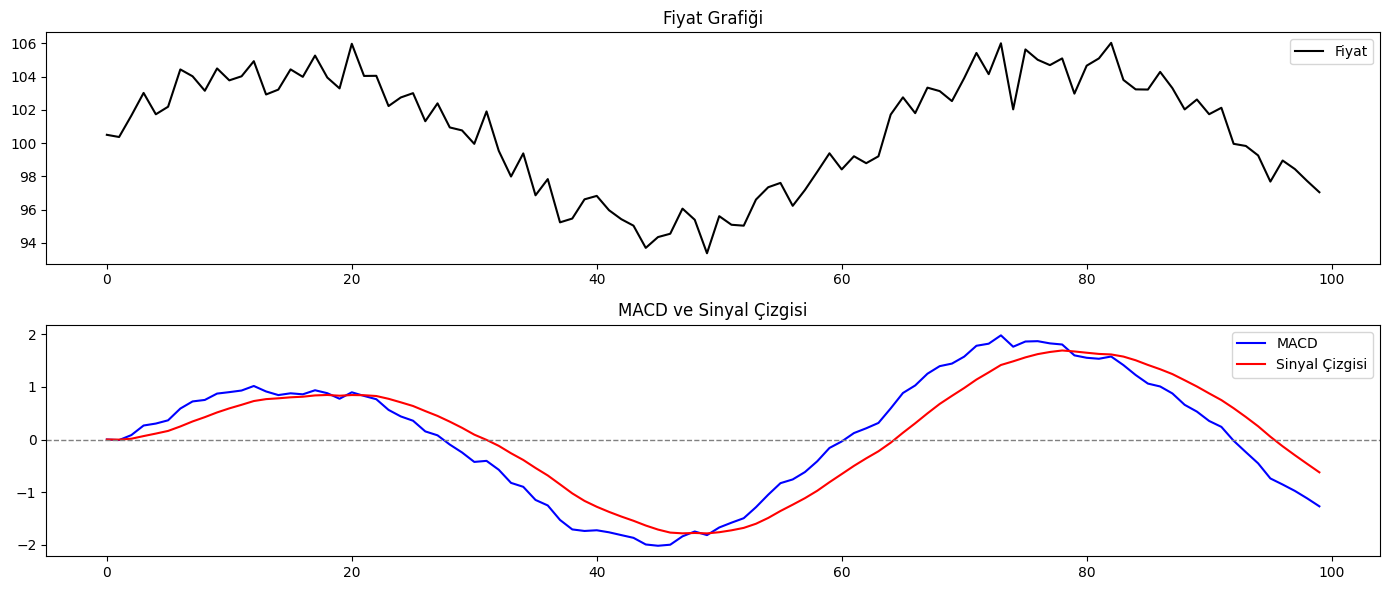

In [2]:
"""
görselleştirme:

Aşağıda MACD (Moving Average Convergence Divergence) stratejisinin nasıl hesaplandığını ve
bunun nasıl görselleştirileceğini gösteren bir Python örneği sunuyorum. Bu örnek, fiyatlar,
MACD çizgisi ve sinyal çizgisini aynı grafikte gösterir:

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Örnek fiyat verisi (örnek olarak sinüzoidal veri kullanalım)
np.random.seed(42)
days = 100
prices = pd.Series(100 + np.sin(np.linspace(0, 10, days)) * 5 + np.random.normal(0, 1, days))

# EMA hesaplama fonksiyonu
def compute_ema(prices, span):
    return prices.ewm(span=span, adjust=False).mean()

# MACD hesaplama fonksiyonu
def compute_macd(prices):
    ema_short = compute_ema(prices, 12)
    ema_long = compute_ema(prices, 26)
    macd = ema_short - ema_long
    signal = compute_ema(macd, 9)
    return macd, signal

# MACD ve sinyal çizgisi hesapla
macd, signal = compute_macd(prices)

# Grafik çizimi
plt.figure(figsize=(14, 6))

# Fiyat grafiği
plt.subplot(2, 1, 1)
plt.plot(prices, label='Fiyat', color='black')
plt.title('Fiyat Grafiği')
plt.legend()

# MACD ve sinyal çizgisi
plt.subplot(2, 1, 2)
plt.plot(macd, label='MACD', color='blue')
plt.plot(signal, label='Sinyal Çizgisi', color='red')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('MACD ve Sinyal Çizgisi')
plt.legend()

plt.tight_layout()
plt.show()

"""
Açıklama:
MACD çizgisi: 12-günlük EMA ile 26-günlük EMA farkı.
Sinyal çizgisi: MACD'nin 9-günlük EMA'sı.
MACD çizgisi sinyalin üstüne çıkarsa alım sinyali, altına inerse satım sinyali olarak yorumlanabilir.
"""

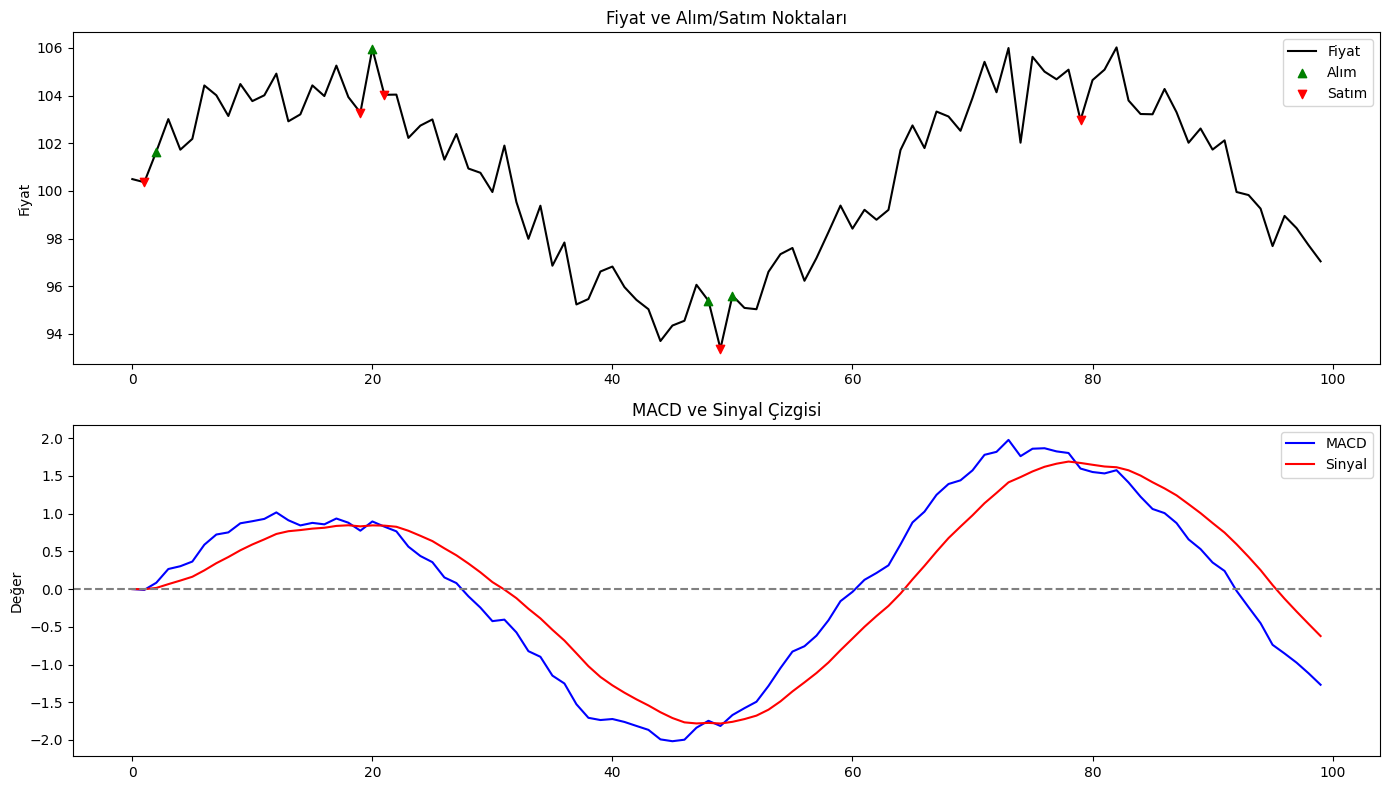

In [3]:
"""
Aşağıda, alım ve satım sinyallerinin MACD ve sinyal çizgisi kesişimlerine göre
otomatik olarak tespit edilip grafiğe eklendiği tam Python kodunu bulabilirsin.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Örnek fiyat verisi
np.random.seed(42)
days = 100
prices = pd.Series(100 + np.sin(np.linspace(0, 10, days)) * 5 + np.random.normal(0, 1, days))

# EMA hesaplama
def compute_ema(prices, span):
    return prices.ewm(span=span, adjust=False).mean()

# MACD hesaplama
def compute_macd(prices):
    ema_short = compute_ema(prices, 12)
    ema_long = compute_ema(prices, 26)
    macd = ema_short - ema_long
    signal = compute_ema(macd, 9)
    return macd, signal

# Alım/satım sinyalleri
def generate_signals(macd, signal):
    buy_signals = []
    sell_signals = []
    for i in range(1, len(macd)):
        if macd[i] > signal[i] and macd[i - 1] <= signal[i - 1]:
            buy_signals.append(i)
        elif macd[i] < signal[i] and macd[i - 1] >= signal[i - 1]:
            sell_signals.append(i)
    return buy_signals, sell_signals

# MACD ve sinyal çizgilerini hesapla
macd, signal = compute_macd(prices)

# Alım/satım sinyallerini bul
buy_signals, sell_signals = generate_signals(macd.values, signal.values)

# Grafik çizimi
plt.figure(figsize=(14, 8))

# 1. Grafik: Fiyat
plt.subplot(2, 1, 1)
plt.plot(prices, label='Fiyat', color='black')
plt.title('Fiyat ve Alım/Satım Noktaları')
plt.ylabel('Fiyat')
plt.scatter(buy_signals, prices.iloc[buy_signals], marker='^', color='green', label='Alım', zorder=5)
plt.scatter(sell_signals, prices.iloc[sell_signals], marker='v', color='red', label='Satım', zorder=5)
plt.legend()

# 2. Grafik: MACD ve Sinyal
plt.subplot(2, 1, 2)
plt.plot(macd, label='MACD', color='blue')
plt.plot(signal, label='Sinyal', color='red')
plt.axhline(0, color='gray', linestyle='--')
plt.title('MACD ve Sinyal Çizgisi')
plt.ylabel('Değer')
plt.legend()

plt.tight_layout()
plt.show()


"""
Açıklama:
Alım sinyali (^ yeşil ok): MACD çizgisi sinyal çizgisini aşağıdan yukarı keserse oluşur.
Satım sinyali (v kırmızı ok): MACD çizgisi sinyal çizgisini yukarıdan aşağı keserse oluşur.
Fiyat grafiğinde bu noktalar işaretlenmiştir.
"""
